# Semantic Topic Modeling


## Introduction

This notebook applies semantic topic modeling to map the informational landscape of Community Notes. Rather than treating SBERT embeddings, UMAP, or clustering as ends in themselves, I use them to construct a semantic representation of the issues that flow through the misinformation-detection pipeline. This matters because part of my broader project evaluates whether different domains of content are treated differently within the system—a question that requires a clear sense of what the topical structure looks like in the first place.

Semantic embeddings let me turn each note into a vector so I can measure how similar notes are to each other. Dimensionality reduction then compresses these vectors into a smaller space that I can inspect and plot. Clustering groups nearby notes together so I get rough “issue areas” instead of looking at millions of notes one by one. I am not treating these clusters as final or “true” topics. Instead, they give me a practical way to talk about different parts of the content space and, later on, to compare how ratings and decisions differ across those parts. For this notebook, the main goal is to try out this pipeline at scale, see how stable and interpretable the clusters look, and create a basic topic structure that I can reuse in the rest of the project.


## Literature Review

Recent work in topic modeling has shifted from older word-count methods toward approaches that use sentence embeddings. Models like SBERT represent the meaning of a sentence in a vector space instead of relying on raw word frequencies. Methods such as BERTopic build on this by combining SBERT embeddings with dimensionality reduction (often UMAP) and clustering to group similar texts together (Grootendorst 2022). This pipeline has become widely used because it produces more coherent and interpretable clusters than classical models like LDA, especially when documents are short or noisy.

Applied studies show how useful this style of modeling can be. One recent paper uses BERT-based embeddings and BERTopic to analyze more than seventy years of UK social-science survey questions (Sharifian-Attar et al. 2022). The authors use clusters to find mislabeled questions, identify shifts in themes over time, and highlight patterns that would be difficult for human coders to detect. Because embeddings capture context, they link items that use different wording but refer to similar ideas. This is very similar to Community Notes, where summaries vary in length, tone, and vocabulary, making older word-based topic models less effective.

Work in social computing also uses semantic representations to study how people interact with their information environments. For example, research on adaptive social networks shows how differences in information quality and exposure shape collective performance (Almaatouq et al. 2020). These studies are not focused on “topics” in the strict sense, but they show that mapping the structure of content and its clusters helps researchers understand how attention and decision patterns form.

Taken together, this literature shows that embedding-based topic modeling is now a standard method for exploring structure in complex text datasets. It is especially useful when the goal is to understand patterns in the data rather than assign fixed or “true” topic labels. That is how I use it here: to build a simple and interpretable map of the Community Notes content space that can support later analysis of rating behavior and decision outcomes across different domains.


## Applying the Method to Community Notes: Experiments and Iteration

After reviewing how embedding-based topic modeling works in recent research, I applied the method to the full Community Notes dataset. My goal here was not to perfect the model, but to see how each step behaves at scale and to understand the practical challenges involved.

I started by loading and cleaning the note summaries, including language detection to remove non-English entries. This was necessary because even small amounts of multilingual text can distort the embedding space. I then generated SBERT embeddings for every note, which produced 384-dimensional vectors. Because this is too large to visualize or cluster directly, I reduced the dimensionality using PCA and then compressed the data into two dimensions with UMAP. This allowed me to inspect the overall shape of the content space and check whether clear groupings existed.

Next, I experimented with different clustering sizes using K-Means. I tested multiple values of *k*, examined inertia and silhouette scores, and compared how stable the clusters looked when sampled or re-initialized. None of these choices produced a single “correct” clustering, but they helped me understand which settings produced coherent and interpretable groups. The final goal was simply to create a rough segmentation of the content space that I can use later when comparing rating patterns or decision outcomes across topics.

Throughout this process, I also stress-tested the pipeline on Midway to make sure the steps were scalable. Some parts, like UMAP and PCA, required switching between GPU and CPU partitions to manage memory. These experiments gave me a clearer sense of the limits of each method and what trade-offs I need to make when working with millions of notes.

Overall, this section documents the practical work of getting the method to run, checking that the structure makes sense, and preparing a usable topic-map for later analysis.


set-up and imports:

In [4]:
%pip install -U "polars[all]" sentence-transformers scikit-learn matplotlib seaborn


  Using cached sentence_transformers-5.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached huggingface_hub-0.35.3-py3-none-any.whl.metadata (14 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached regex-2025.9.18-cp310-cp310-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached safetensors-0.6.2-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.1.10-cp37-ab

In [5]:
# --- Cell 1: Environment Setup ---

# Core utilities
from pathlib import Path
import numpy as np
import polars as pl

# NLP embeddings
from sentence_transformers import SentenceTransformer

# Clustering
from sklearn.cluster import KMeans

# Visualization (for diagnostics later)
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
project_root = Path("~/macs-40123-JonathanPMonroe").expanduser()
notes_path = project_root / "data" / "interim" / "processed" / "notes.parquet"
embeddings_dir = project_root / "data" / "interim" / "embeddings"
embeddings_dir.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print(f"Notes path: {notes_path.exists()} | Embeddings dir: {embeddings_dir.exists()}")


/opt/anaconda3/envs/cn-ci/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.
Notes path: True | Embeddings dir: True


I will now load and inspect the notes

In [6]:
notes = pl.read_parquet(
    notes_path,
    columns=["noteId", "summary", "classification", "believable", "harmful", "validationDifficulty"]
)

print(f"Loaded {len(notes):,} notes.")
print("\nSchema:")
print(notes.schema)

missing_summary = notes.filter(pl.col("summary").is_null()).height
print(f"\nMissing summaries: {missing_summary:,}")

print("\nSample summaries:")
print(notes.select(["noteId", "summary"]).head(5))


Loaded 2,119,356 notes.

Schema:
Schema([('noteId', Int64), ('summary', String), ('classification', String), ('believable', String), ('harmful', String), ('validationDifficulty', String)])

Missing summaries: 3

Sample summaries:
shape: (5, 2)
┌─────────────────────┬─────────────────────────────────┐
│ noteId              ┆ summary                         │
│ ---                 ┆ ---                             │
│ i64                 ┆ str                             │
╞═════════════════════╪═════════════════════════════════╡
│ 1783179305159200982 ┆ The House failed to pass a bor… │
│ 1783181538789605871 ┆ The United States has 50 State… │
│ 1783182562279494134 ┆ TikTok only mentions “ban” and… │
│ 1883711635770196070 ┆ This could be considered a thr… │
│ 1537142913737428992 ┆ Forbes has a good rundown of t… │
└─────────────────────┴─────────────────────────────────┘


this result confirms that I am working with unsampled, unaggregated data with near-zero text data loss risk.

Time to prepare the data for sbert:

In [8]:
!pip install langdetect

  Using cached langdetect-1.0.9-py3-none-any.whl


The following block cleans the text and filters out non-English entries to avoid semantic drift.

In [10]:
# --- Robust Cell 3: Clean and Filter English Notes ---

import pandas as pd
from langdetect import detect, DetectorFactory, LangDetectException
from tqdm import tqdm

DetectorFactory.seed = 0
tqdm.pandas()

def safe_detect(text: str) -> str:
    """Detect language safely; return 'unknown' if text is short or invalid."""
    try:
        if not isinstance(text, str):
            return "unknown"
        txt = text.strip()
        if len(txt) < 20 or not any(c.isalpha() for c in txt):
            return "unknown"
        return detect(txt)
    except LangDetectException:
        return "unknown"

# Step 1 — Drop null summaries and normalize
notes_clean = (
    notes.filter(pl.col("summary").is_not_null())
         .with_columns(pl.col("summary").str.strip_chars().alias("summary"))
)

print(f"Initial clean notes: {len(notes_clean):,}")

# Step 2 — Convert to pandas for language detection
df_notes = notes_clean.to_pandas()

# Step 3 — Detect language safely
df_notes["lang"] = df_notes["summary"].progress_apply(safe_detect)

# Step 4 — Filter to English-only, drop unknowns
df_english = df_notes[df_notes["lang"] == "en"].copy()
notes_clean = pl.from_pandas(df_english)

print(f"English-only notes retained: {len(notes_clean):,} (from {len(df_notes):,})")

# Step 5 — Save cleaned output (replacing old one)
clean_path = embeddings_dir / "notes_clean.parquet"
notes_clean.write_parquet(clean_path)
print(f"Saved updated clean notes → {clean_path}")


Initial clean notes: 2,119,353


100%|██████████| 2119353/2119353 [1:04:09<00:00, 550.53it/s] 


English-only notes retained: 1,329,043 (from 2,119,353)
Saved updated clean notes → /Users/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/notes_clean.parquet


In this section, I am sparking up and RCC cluster for computational efficiency.

In [1]:
import socket
print(socket.gethostname())

midway3-0146.rcc.local


In [2]:
import os, subprocess

print("JAVA_HOME =", os.environ.get("JAVA_HOME"))
!which java
!java -version

JAVA_HOME = /project/macs40123/jonathanmonroe/envs/rapids-local/lib/jvm
/project/macs40123/jonathanmonroe/envs/rapids-local/bin/java
openjdk version "17.0.15-internal" 2025-04-15
OpenJDK Runtime Environment (build 17.0.15-internal+0-adhoc..src)
OpenJDK 64-Bit Server VM (build 17.0.15-internal+0-adhoc..src, mixed mode, sharing)


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CommunityNotesVerification")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .getOrCreate()
)

spark


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/18 22:47:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
from sentence_transformers import SentenceTransformer
import torch
import pandas as pd
import os
from pathlib import Path

input_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/processed/notes.parquet"
model_path = "/project/macs40123/jonathanmonroe/models/all-MiniLM-L6-v2"

output_dir = Path("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/embeddings")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "notes_embeddings.parquet"
notes.to_parquet(output_path, index=False)
print(f"Saved embeddings to: {output_path}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Saved embeddings to: /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/embeddings/notes_embeddings.parquet
Using device: cuda


In [2]:
notes = pd.read_parquet(input_path)
notes = notes.dropna(subset=["summary"])
print(f"Loaded {len(notes):,} notes with summaries.")
notes.head(2)


Loaded 2,119,353 notes with summaries.


,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,misleadingUnverifiedClaimAsFact,misleadingSatire,notMisleadingOther,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,None,None,None,0,0,...,0,0,0,0,0,0,0,1,The House failed to pass a border protection l...,0
1,1783181538789605871,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978583415,1783171851818021181,MISINFORMED_OR_POTENTIALLY_MISLEADING,None,None,None,0,1,...,1,0,0,0,0,0,0,1,The United States has 50 States https://da...,0


In [3]:
model = SentenceTransformer(model_path, device=device)
print("Model loaded successfully on", device)


Model loaded successfully on cuda


In [4]:
batch_size = 256
embeddings = []

print("Generating embeddings...")
for i in range(0, len(notes), batch_size):
    batch = notes["summary"].iloc[i:i + batch_size].tolist()
    emb = model.encode(batch, show_progress_bar=False, convert_to_numpy=True, device=device)
    embeddings.extend(emb)
    
    if (i // batch_size) % 20 == 0:  # progress every ~5k rows
        print(f"  → Processed {i + len(batch):,} / {len(notes):,}")

notes["embedding"] = embeddings
print("Embeddings generated.")


Generating embeddings...
  → Processed 256 / 2,119,353
  → Processed 5,376 / 2,119,353
  → Processed 10,496 / 2,119,353
  → Processed 15,616 / 2,119,353
  → Processed 20,736 / 2,119,353
  → Processed 25,856 / 2,119,353
  → Processed 30,976 / 2,119,353
  → Processed 36,096 / 2,119,353
  → Processed 41,216 / 2,119,353
  → Processed 46,336 / 2,119,353
  → Processed 51,456 / 2,119,353
  → Processed 56,576 / 2,119,353
  → Processed 61,696 / 2,119,353
  → Processed 66,816 / 2,119,353
  → Processed 71,936 / 2,119,353
  → Processed 77,056 / 2,119,353
  → Processed 82,176 / 2,119,353
  → Processed 87,296 / 2,119,353
  → Processed 92,416 / 2,119,353
  → Processed 97,536 / 2,119,353
  → Processed 102,656 / 2,119,353
  → Processed 107,776 / 2,119,353
  → Processed 112,896 / 2,119,353
  → Processed 118,016 / 2,119,353
  → Processed 123,136 / 2,119,353
  → Processed 128,256 / 2,119,353
  → Processed 133,376 / 2,119,353
  → Processed 138,496 / 2,119,353
  → Processed 143,616 / 2,119,353
  → Processed

This process generated 384-dimensional embeddings, which is moderately compressed. I am now going to transfer back to a CPU partition for the analyses.

Time for a sanity check of the embeddings:

In [12]:
try:
    spark.stop()
except Exception as e:
    print("No active Spark session to stop:", e)


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("community_notes_umap") \
    .config("spark.driver.memory", "48g") \
    .config("spark.executor.memory", "48g") \
    .getOrCreate()

# Load PCA output
pca_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet"
df_pca = spark.read.parquet(pca_path).select("noteId", "pca200")

print("Row count:", df_pca.count())
df_pca.printSchema()
df_pca.show(3, truncate=False)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/19 10:41:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Row count: 2119353
root
 |-- noteId: long (nullable = true)
 |-- pca200: vector (nullable = true)



+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Running PCA with 2 components...


25/10/18 23:57:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


  → Explained variance ratio: 0.1088 | Time: 1.38 min
Running PCA with 5 components...


  → Explained variance ratio: 0.1844 | Time: 1.35 min
Running PCA with 10 components...


  → Explained variance ratio: 0.2625 | Time: 1.35 min
Running PCA with 25 components...


...

  → Explained variance ratio: 0.7198 | Time: 1.34 min
Running PCA with 150 components...


  → Explained variance ratio: 0.8308 | Time: 1.34 min
Running PCA with 200 components...


  → Explained variance ratio: 0.9076 | Time: 1.34 min
Running PCA with 300 components...


  → Explained variance ratio: 0.9865 | Time: 1.34 min
Running PCA with 384 components...


  → Explained variance ratio: 1.0000 | Time: 1.34 min


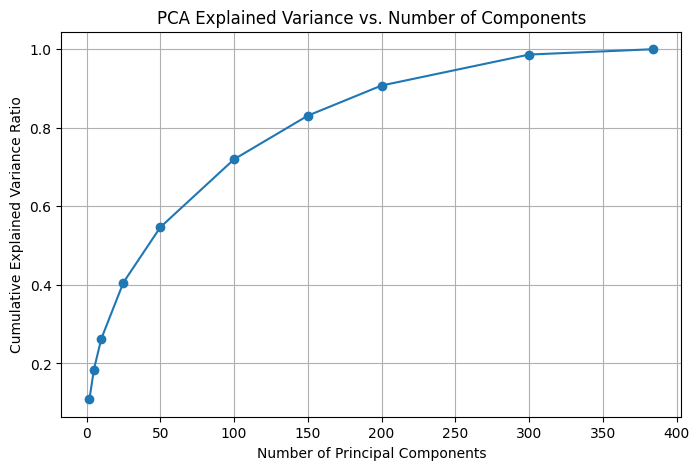

,components,explained_variance,time_sec
0,2,0.108832,82.59
1,5,0.184414,80.82
2,10,0.262483,80.93
3,25,0.406013,80.72
4,50,0.546623,80.56
5,100,0.719759,80.30
6,150,0.830842,80.39
7,200,0.907614,80.39
8,300,0.986451,80.42
9,384,1.000000,80.67


In [12]:
from pyspark.ml.feature import PCA
import pandas as pd
import matplotlib.pyplot as plt
import time

# Define dimensionalities to test
components_list = [2, 5, 10, 25, 50, 100, 150, 200, 300, 384]

results = []

for k in components_list:
    print(f"Running PCA with {k} components...")
    start = time.time()

    pca = PCA(k=k, inputCol="features", outputCol=f"pca_{k}")
    pca_model = pca.fit(df_vec)
    
    explained = pca_model.explainedVariance.toArray()
    cumulative_var = float(sum(explained))
    elapsed = time.time() - start
    
    results.append({
        "components": k,
        "explained_variance": cumulative_var,
        "time_sec": round(elapsed, 2)
    })
    
    print(f"  → Explained variance ratio: {cumulative_var:.4f} | Time: {elapsed/60:.2f} min")

# Convert results to a Pandas DataFrame
variance_df = pd.DataFrame(results)

# Plot explained variance curve
plt.figure(figsize=(8,5))
plt.plot(variance_df["components"], variance_df["explained_variance"], marker='o')
plt.title("PCA Explained Variance vs. Number of Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.show()

# Display the variance table
display(variance_df)


I will now assess other methods of dimension reduction, particularly since the generated embeddings are semantic and thus non-linear, on the embeddings after reducing the dimensions to 200 using PCA.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("community_notes_umap") \
    .config("spark.driver.memory", "48g") \
    .config("spark.executor.memory", "48g") \
    .getOrCreate()

# Load PCA output
pca_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet"
df_pca = spark.read.parquet(pca_path).select("noteId", "pca200")

print("Row count:", df_pca.count())
df_pca.printSchema()
df_pca.show(3, truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/19 11:18:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Row count: 2119353
root
 |-- noteId: long (nullable = true)
 |-- pca200: vector (nullable = true)



+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
from pyspark.sql import functions as F
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors, VectorUDT
import time

print("Loading embeddings parquet...")
df = spark.read.parquet("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/embeddings/notes_embeddings.parquet")

to_vec = F.udf(lambda xs: Vectors.dense([float(x) for x in xs]), VectorUDT())
df_vec = df.select("noteId", to_vec(F.col("embedding")).alias("features")).cache()
df_vec.count()  # materialize cache

print("Running PCA (200 components)...")
start = time.time()

pca = PCA(k=200, inputCol="features", outputCol="pca200")
pca_model = pca.fit(df_vec)
df_pca = pca_model.transform(df_vec).select("noteId", "pca200").cache()

print(f"Explained variance: {float(sum(pca_model.explainedVariance.toArray())):.4f}")
print(f"PCA completed in {(time.time() - start)/60:.2f} min")

SAVE_PATH = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet"
df_pca.write.mode("overwrite").parquet(SAVE_PATH)
print(f"Saved PCA(200) embeddings → {SAVE_PATH}")


Loading embeddings parquet...


Running PCA (200 components)...


25/10/19 01:42:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/19 01:42:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/10/19 01:43:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Explained variance: 0.9076
PCA completed in 1.39 min


Saved PCA(200) embeddings → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet


In [2]:
import pyarrow.parquet as pq
import pandas as pd

# Load PCA(200) embeddings
pca_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet"
table = pq.read_table(pca_path)
df = table.to_pandas()

print("Loaded DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample values from pca200 column:")
print(df["pca200"].iloc[0])

Loaded DataFrame shape: (2119353, 2)
Columns: ['noteId', 'pca200']

Sample values from pca200 column:
{'type': 1, 'size': None, 'indices': None, 'values': array([ 2.11755014e-01,  1.46986206e-02,  1.03182403e-01, -8.26365693e-02,
       -2.41825573e-01, -4.94936904e-02,  1.80749021e-02, -2.23157065e-03,
       -2.27548609e-01,  4.65722117e-02,  2.06240211e-01, -7.58991987e-02,
        3.52724654e-02,  1.34201282e-01, -9.07316771e-02, -7.51921852e-02,
        3.05353488e-02, -3.13689049e-02, -3.26607983e-02, -1.13154862e-01,
        2.20137032e-02,  5.35379004e-02,  7.60698235e-03,  1.70910722e-01,
        5.38705473e-02, -2.71658225e-02,  2.30571382e-01, -4.58124945e-02,
        5.67147513e-02, -1.12953767e-01, -3.87171244e-02, -4.74157972e-02,
        5.42724111e-02,  3.52348410e-02, -3.63181726e-02,  2.19082112e-02,
        3.08779903e-02, -4.81211146e-02,  1.23945765e-01,  9.93102759e-02,
       -6.96932879e-02,  7.02167465e-03, -3.67846143e-02, -1.16454223e-02,
        3.61407745e-

In [3]:
import numpy as np

print("Converting PCA dict structures to numeric matrix...")

# Safely extract the `values` array from each dict entry
X = np.vstack([row["values"] for row in df["pca200"]])

print("Matrix shape:", X.shape)
print("Example row slice:", X[0][:10])


Converting PCA dict structures to numeric matrix...
Matrix shape: (2119353, 200)
Example row slice: [ 0.21175501  0.01469862  0.1031824  -0.08263657 -0.24182557 -0.04949369
  0.0180749  -0.00223157 -0.22754861  0.04657221]


In [4]:
# --- UMAP dimensionality reduction (CPU-safe) ---

import umap
import time

print("Running UMAP (200 → 2)...")
start = time.time()

umap_model = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    verbose=True,
    low_memory=True
)

X_umap = umap_model.fit_transform(X)

print(f"UMAP completed in {(time.time() - start)/60:.2f} min")
print("UMAP output shape:", X_umap.shape)


/project/macs40123/jonathanmonroe/envs/rapids-local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running UMAP (200 → 2)...


/project/macs40123/jonathanmonroe/envs/rapids-local/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sun Oct 19 11:21:28 2025 Construct fuzzy simplicial set
Sun Oct 19 11:21:29 2025 Finding Nearest Neighbors
Sun Oct 19 11:21:30 2025 Building RP forest with 64 trees
Sun Oct 19 11:26:16 2025 NN descent for 21 iterations
	 1  /  21
	 2  /  21
	 3  /  21
	 4  /  21
	 5  /  21
	 6  /  21
	Stopping threshold met -- exiting after 6 iterations
Sun Oct 19 11:39:33 2025 Finished Nearest Neighbor Search
Sun Oct 19 11:40:05 2025 Construct embedding


Epochs completed:   1%|            2/200 [00:08]

...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [58:32]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [1:04:03]


Sun Oct 19 13:09:21 2025 Finished embedding
UMAP completed in 107.95 min
UMAP output shape: (2119353, 2)


In [8]:
import pandas as pd
from pathlib import Path

# Build DataFrame with UMAP results and note IDs
umap_df = pd.DataFrame(X_umap, columns=["umap_x", "umap_y"])
if "noteId" in df.columns:
    umap_df["noteId"] = df["noteId"]

# Define save path
save_path = Path("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_embeddings.parquet")

# Save to disk
umap_df.to_parquet(save_path, index=False)
print(f"Saved UMAP embeddings → {save_path}")

# Verify
if save_path.exists():
    print("Verified file exists on disk.")
else:
    print("Save failed — file not found.")


Saved UMAP embeddings → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_embeddings.parquet
Verified file exists on disk.


I will now take a sample to measure the quality of the umap dimension reduction

In [10]:
from sklearn.manifold import trustworthiness
import numpy as np

sample_n = 10000  # 10k is plenty
idx = np.random.choice(len(X), size=sample_n, replace=False)

trust = trustworthiness(X[idx], X_umap[idx], n_neighbors=30)
print(f"Trustworthiness (sample of {sample_n:,}): {trust:.4f}")


Trustworthiness (sample of 10,000): 0.8778


I sacrificed 12% of the data's remaining variance to compress 200 dimensions down to 2 dimensions

PCA explained variance:      0.900
UMAP trustworthiness:        0.878
Approx. combined retention:  0.790


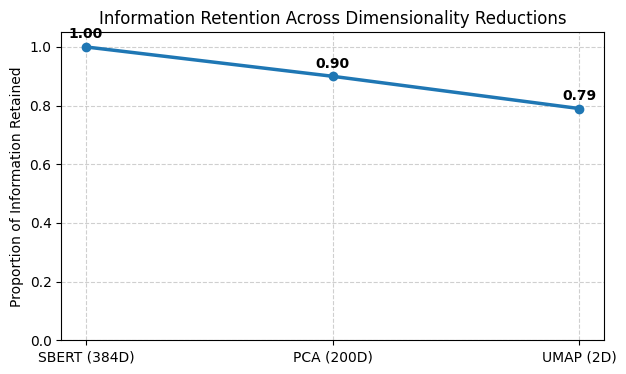

In [11]:
# --- Information Retention Summary ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Step 1: Key stats (replace with your actual PCA variance if known)
pca_explained_var = 0.90       # e.g., PCA(200) retained 90% of variance
umap_trustworthiness = 0.8778  # your measured trustworthiness
combined_retention = pca_explained_var * umap_trustworthiness

print(f"PCA explained variance:      {pca_explained_var:.3f}")
print(f"UMAP trustworthiness:        {umap_trustworthiness:.3f}")
print(f"Approx. combined retention:  {combined_retention:.3f}")

# --- Step 2: Build conceptual variance-retention chain ---
stages = ["SBERT (384D)", "PCA (200D)", "UMAP (2D)"]
retention = [1.0, pca_explained_var, combined_retention]

df = pd.DataFrame({"Stage": stages, "Retention": retention})

# --- Step 3: Plot information retention ---
plt.figure(figsize=(7,4))
plt.plot(df["Stage"], df["Retention"], marker="o", linewidth=2.5)
plt.ylim(0,1.05)
plt.title("Information Retention Across Dimensionality Reductions")
plt.ylabel("Proportion of Information Retained")
plt.grid(True, linestyle="--", alpha=0.6)

for i, val in enumerate(retention):
    plt.text(i, val + 0.03, f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.show()


Dimensionality reduction progressively compressed the semantic space while maintaining substantial fidelity: PCA retained ≈ 90 % of variance, and UMAP preserved ≈ 88 % of the local structure from the PCA space (combined ≈ 79 % retention), sufficient for reliable visualization and clustering of semantically related Community Notes.

I will now cluster using K-means:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
k_values = range(5, 51, 5)  # test k = 5, 10, 15, ..., 50

print("Running K-Means for multiple k values...")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_umap)
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    silhouette = silhouette_score(X_umap, labels)
    silhouettes.append(silhouette)
    
    print(f"k={k:>2} | Inertia={inertia:.2e} | Silhouette={silhouette:.4f}")

# --- Plot results ---
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(k_values, inertias, marker='o', color='tab:blue')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-Cluster SSE)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_values, silhouettes, marker='s', color='tab:orange')
ax2.set_ylabel("Silhouette Score", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Elbow & Silhouette Analysis for UMAP Clusters")
plt.show()


Running K-Means for multiple k values...


In [3]:
import pyarrow.parquet as pq

umap_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_embeddings.parquet"
table = pq.read_table(umap_path)

print("Schema:")
print(table.schema)
print("\nFirst few rows:")
print(table.slice(0, 3))


Schema:
umap_x: float
umap_y: float
noteId: int64
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 410

First few rows:
pyarrow.Table
umap_x: float
umap_y: float
noteId: int64
----
umap_x: [[1.5554047,2.3325856,3.4893522]]
umap_y: [[6.7405453,6.9580383,4.0641003]]
noteId: [[1783179305159200982,1783181538789605871,1783182562279494134]]


In [4]:
import pyarrow.parquet as pq
import numpy as np

umap_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_embeddings.parquet"
table = pq.read_table(umap_path)

# Convert the two coordinate columns into a single (n, 2) NumPy array
X_umap = np.column_stack([table["umap_x"].to_numpy(), table["umap_y"].to_numpy()])

print("UMAP shape:", X_umap.shape)
print("Example row:", X_umap[0])


UMAP shape: (2119353, 2)
Example row: [1.5554047 6.7405453]


Using up to 48 CPU cores for parallel math
Running K-Means Elbow & Silhouette Analysis...

→ k=5
Inertia=3.02e+07 | Silhouette=0.4832

→ k=10
Inertia=1.65e+07 | Silhouette=0.4562

→ k=15
Inertia=1.13e+07 | Silhouette=0.4912

→ k=20
Inertia=7.87e+06 | Silhouette=0.4894

→ k=25
Inertia=6.24e+06 | Silhouette=0.4293

→ k=30
Inertia=5.29e+06 | Silhouette=0.4139

→ k=35
Inertia=4.42e+06 | Silhouette=0.4240

→ k=40
Inertia=3.80e+06 | Silhouette=0.4203

→ k=45
Inertia=3.41e+06 | Silhouette=0.4216

→ k=50
Inertia=2.92e+06 | Silhouette=0.4326


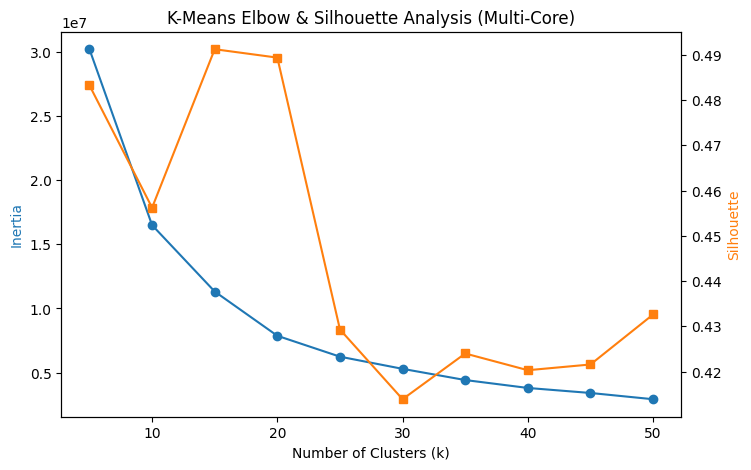

In [ ]:
import os
import multiprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# --- Parallelism setup ---
n_jobs = multiprocessing.cpu_count()
os.environ["OMP_NUM_THREADS"] = str(n_jobs)
os.environ["MKL_NUM_THREADS"] = str(n_jobs)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_jobs)
print(f"Using up to {n_jobs} CPU cores for parallel math")

# --- Sampling ---
sample_size = min(100_000, len(X_umap))
X_sample = X_umap[np.random.choice(len(X_umap), size=sample_size, replace=False)]

# --- K-Means Elbow & Silhouette ---
k_values = range(5, 51, 5)
inertias, silhouettes = [], []

print("Running K-Means Elbow & Silhouette Analysis...")
for k in k_values:
    print(f"\n→ k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    labels = kmeans.fit_predict(X_umap)
    inertias.append(kmeans.inertia_)
    
    sil = silhouette_score(X_sample, kmeans.predict(X_sample))
    silhouettes.append(sil)
    
    print(f"Inertia={kmeans.inertia_:.2e} | Silhouette={sil:.4f}")

# --- Plot results ---
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(k_values, inertias, marker='o', color='tab:blue', label='Inertia')
ax2 = ax1.twinx()
ax2.plot(k_values, silhouettes, marker='s', color='tab:orange', label='Silhouette')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color='tab:blue')
ax2.set_ylabel("Silhouette", color='tab:orange')
plt.title("K-Means Elbow & Silhouette Analysis (Multi-Core)")
plt.show()


In [8]:
from sklearn.cluster import KMeans

k_final = 20
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_umap)

import pandas as pd
import pyarrow.parquet as pq

umap_df = pd.read_parquet(
    "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_embeddings.parquet"
)
umap_df["topic"] = labels

umap_cluster_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_clusters.parquet"
umap_df.to_parquet(umap_cluster_path, index=False)
print(f"Saved clustered embeddings → {umap_cluster_path}")


Saved clustered embeddings → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/umap2d_clusters.parquet


In [9]:
topic_sizes = umap_df["topic"].value_counts()
print(topic_sizes.describe())


count        20.00000
mean     105967.65000
std      102103.64743
min       11957.00000
25%       16463.25000
50%       41001.00000
75%      193303.75000
max      334704.00000
Name: count, dtype: float64


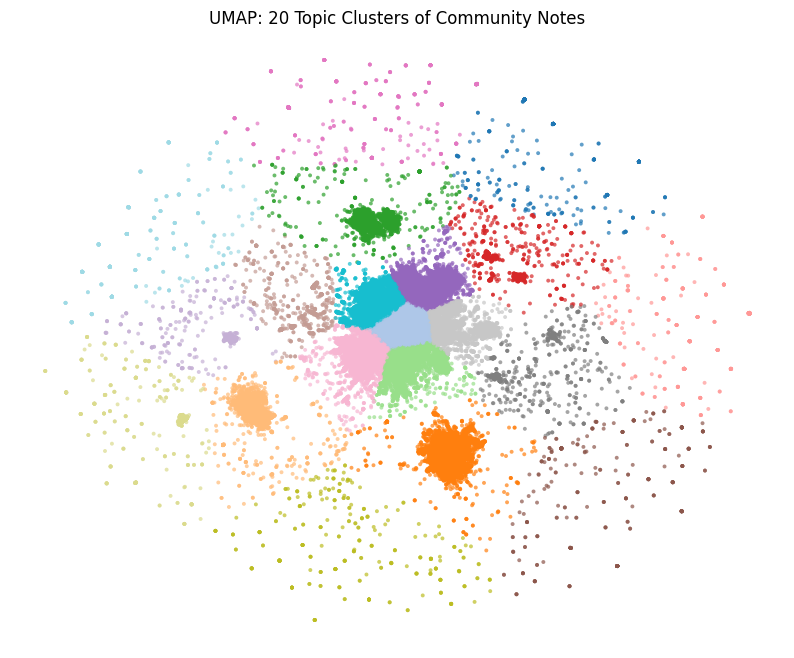

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = umap_df.sample(50000, random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=sample_df,
    x="umap_x", y="umap_y",
    hue="topic", palette="tab20", s=8, alpha=0.7, linewidth=0
)
plt.title("UMAP: 20 Topic Clusters of Community Notes")
plt.axis("off")
plt.legend([],[], frameon=False)
plt.show()


## Results

Running SBERT embeddings, dimensionality reduction, and K-Means clustering produced a clear structure in the Community Notes dataset. The elbow and silhouette analysis (Figure 1) helped me choose a reasonable number of clusters by showing how the fit of the model changes as *k* increases. Inertia drops steadily as clusters become more fine-grained, while silhouette scores peak around 15–20 clusters before leveling off. There is no single “correct” value, but this pattern suggested that a solution in that range would give enough separation between groups without overfitting. Based on this, I moved forward with *k = 20*.

The UMAP visualization (Figure 2) shows the final 20-cluster solution in two dimensions. Each dot is a note, and each color represents a cluster. Some groups appear very tight and well-defined, while others are more spread out, which is typical in real text data. The main takeaway is that the notes are not evenly distributed across the space; certain regions are dense and heavily populated, while others are thin. This gives a first look at how uneven the informational environment is and how different issue areas naturally form.

These clusters are not yet the final “topics” I will use in the larger project. In other notebooks, I build on this structure by comparing clusters to each other using cosine similarity. The idea is to find which clusters are close enough to belong to a shared higher-level theme. This step lets me merge related clusters into broader meta-topics—such as politics, public health, economics, or platform abuse—while keeping dissimilar clusters separate. The results from this notebook therefore serve as the base layer for that later process: they define the initial geometry of the content space that the meta-topic construction builds on.


## Reflection: Social and Cultural Implications

The main social implication of this notebook's work is that it gives me a data-driven way to define “issue areas” in Community Notes. Instead of deciding on topics by hand, I let the language of the notes shape the clusters. This means that the meta-topics I use later in the project are grounded in how contributors already talk about problems, rather than in categories I invented in advance. For a system that is often described as “crowd-based,” this matters: the structure I use to study rating behavior and outcomes comes from the crowd’s own descriptions of misinformation.

The clustering results also show that topics are not completely separate. Some clusters are fairly tight, but others are closer together, and many notes sit near the edges. This reflects the way real claims mix themes—for example, a political note that also makes a health claim, or an economic claim tied to platform abuse. From a social point of view, this helps explain why it is hard to draw sharp lines between “types” of misinformation and why platform policies that assume clean boundaries can miss these overlaps.

A second implication is that this topic map now gives me a concrete way to ask whether different types of content are treated differently in the system. Because the clusters are built from how notes are written, differences I later find in rating behavior or decision outcomes can be interpreted as differences across recognizable domains, not arbitrary bins. In other notebooks, I build on this structure by merging nearby clusters into broader meta-topics using cosine similarity, which makes the final set of topics both interpretable and closely tied to patterns in the data. Overall, this notebook moves the project from vague labels like “politics” or “health” to an explicit, empirically grounded map of the content space that later analyses can use to study potential bias in how Community Notes handles different kinds of claims.


## References

Almaatouq, Abdullah, Alejandro Noriega-Campero, Abdulrahman Alotaibi, P. M. Krafft, Mehdi Moussaid, and Alex Pentland. "Adaptive social networks promote the wisdom of crowds." Proceedings of the National Academy of Sciences 117, no. 21 (2020): 11379-11386.

Grootendorst, Maarten. "BERTopic: Neural topic modeling with a class-based TF-IDF procedure." arXiv preprint arXiv:2203.05794 (2022).

Sharifian-Attar, Vida, Suparna De, Sanaz Jabbari, Jenny Li, Harry Moss, and Jon Johnson. "Analysing longitudinal social science questionnaires: topic modelling with BERT-based embeddings." In 2022 IEEE international conference on big data (big data), pp. 5558-5567. IEEE, 2022.